# Final Insights

## Is UPI Changing the Way India Pays?

## Objective

This notebook summarizes the key findings from the UPI transaction analysis and the RBI payment ecosystem comparison.

The goal of this report is to understand the impact of UPI on how India pays, and whether it has replaced, coexisted with, or affected other payment methods such as debit cards, credit cards, and ATM withdrawals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [7]:
upi = pd.read_csv("../data/processed/upi_master.csv")
payments = pd.read_csv("../data/processed/payment_ecosystem_clean.csv")

upi['Month'] = pd.to_datetime(upi['Month'])
payments['Month'] = pd.to_datetime(payments['Month'])

upi = upi.sort_values('Month').reset_index(drop = 'true')
payments = payments.sort_values('Month').reset_index(drop = 'true')

In [16]:
print('Upi Dataset')
print(upi.shape)
print(upi["Month"].min(),"to", upi['Month'].max())

print('\nPayment Ecosystem Database')
print(payments.shape)
print(payments["Month"].min(),"to", payments['Month'].max())

Upi Dataset
(122, 4)
2016-04-01 00:00:00 to 2026-05-01 00:00:00

Payment Ecosystem Database
(77, 13)
2019-11-01 00:00:00 to 2026-03-01 00:00:00


In [18]:
upi.columns

Index(['Month', 'Banks', 'Volume_Mn', 'Value_Cr'], dtype='object')

In [19]:
payments.columns

Index(['Month', 'UPI_Volume_inlakhs', 'UPI_Value_inCr',
       'Credit_Volume_inlakhs', 'Credit_Value_inCr', 'Debit_Volume_inlakhs',
       'Debit_Value_inCr', 'ATM_Debit_Volume_inlakhs', 'ATM_Debit_Value_inCr',
       'UPI_ATV', 'Debit_ATV', 'Credit_ATV', 'ATM_Debit_ATV'],
      dtype='object')

In [20]:
# UPI CAGR calculation
cagr_data = upi[upi['Volume_Mn'] > 0].copy()

start_volume = cagr_data.iloc[0]['Volume_Mn']
end_volume = cagr_data.iloc[-1]['Volume_Mn']

num_years = (
    (cagr_data['Month'].max() - cagr_data['Month'].min()).days
    / 365.25
)

upi_cagr = ((end_volume / start_volume) ** (1 / num_years) - 1) * 100


In [21]:
# Correlations from payment ecosystem dataset
upi_debit_corr = payments['UPI_Volume_inlakhs'].corr(
    payments['Debit_Volume_inlakhs']
)

upi_credit_corr = payments['UPI_Volume_inlakhs'].corr(
    payments['Credit_Volume_inlakhs']
)

upi_atm_corr = payments['UPI_Volume_inlakhs'].corr(
    payments['ATM_Debit_Volume_inlakhs']
)

In [33]:
kpi_summary= pd.DataFrame({
    'kpi' : [
        'UPI CAGR',
        'UPI vs Debit Card Volume Correlation',
        'UPI vs Credit Card Volume Correlation',
        'UPI vs ATM Debit Withdrawal Correlation'
        
    ],
    'Value' : [
        f'{upi_cagr:.2f}%',
        round(upi_debit_corr,3),
        round(upi_credit_corr,3),
        round(upi_atm_corr,3)
        
    ],
    
     'Interpretation': [
        'Long-term UPI adoption growth',
        'Strong negative association',
        'Strong positive association',
        'Moderate negative association'
    ]
})

kpi_summary

,kpi,Value,Interpretation
0,UPI CAGR,255.14%,Long-term UPI adoption growth
1,UPI vs Debit Card Volume Correlation,-0.925,Strong negative association
2,UPI vs Credit Card Volume Correlation,0.986,Strong positive association
3,UPI vs ATM Debit Withdrawal Correlation,-0.473,Moderate negative association


## KPI Summary

The KPI summary highlights the major findings from this project.

UPI showed exceptional long-term growth, with a CAGR of approximately 255%. This reflects the rapid expansion of UPI from a low initial base into a major payment system widely used across India.

The correlation analysis shows that UPI transaction volume had a strong negative relationship with debit card transaction volume, a moderate negative relationship with ATM debit withdrawals, and a strong positive relationship with credit card transaction volume.

This suggests that UPI's impact was not uniform across all payment methods. Debit cards were the most negatively associated with UPI growth, while credit cards continued to grow alongside UPI because they serve different use cases, such as credit access, short-term financing, rewards, and larger purchases.


# Insight 1: UPI Adoption Scaled Rapidly

UPI transaction volume grew from a small base in 2016 to a large-scale payment system by 2026. This chart provides the long-term adoption context for the rest of the analysis.

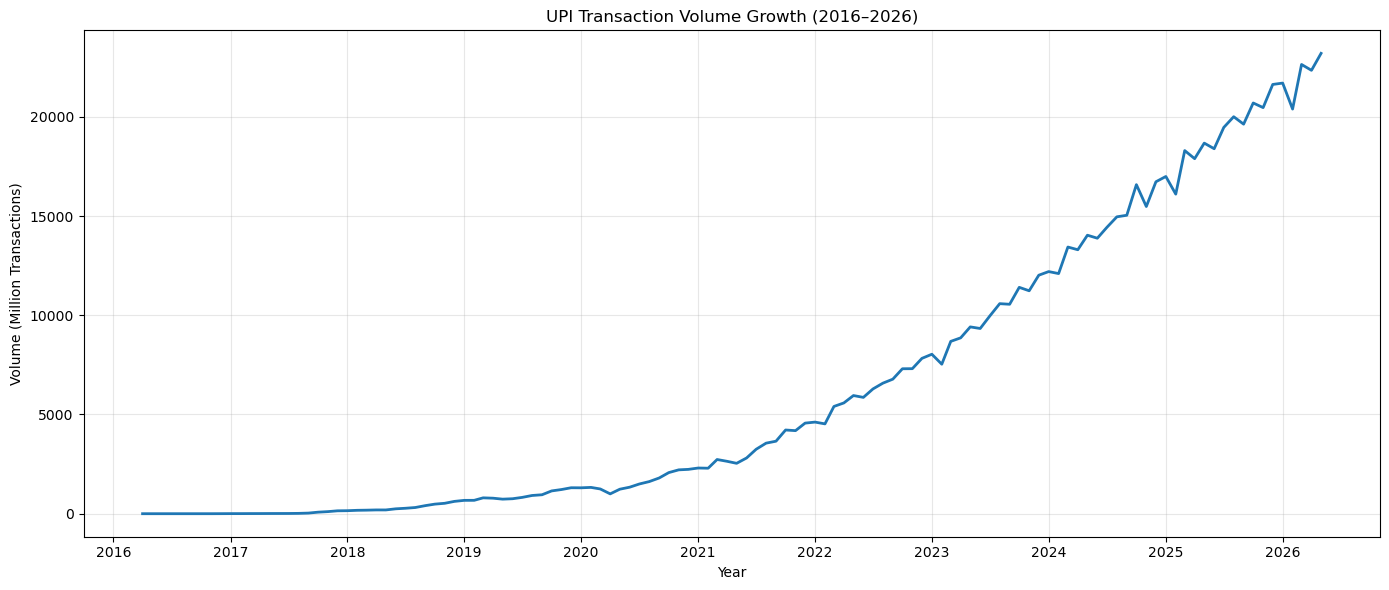

In [42]:
plt.figure(figsize=(14,6))

plt.plot(
    upi['Month'],
    upi['Volume_Mn'],
    linewidth=2
)

plt.title('UPI Transaction Volume Growth (2016–2026)')
plt.xlabel('Year')
plt.ylabel('Volume (Million Transactions)')

years = range(2016, 2027)
plt.xticks(
    [pd.Timestamp(f'{year}-01-01') for year in years],
    years
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Observation



During the early adoption phase of UPI, from 2016 to early 2020, transaction volume remained relatively low. UPI was still a new payment system, and many users continued to rely on cash and other traditional payment methods for daily transactions.



After 2020, UPI transaction volume increased rapidly. This period coincided with the COVID-19 lockdown in India, when digital and contactless payment methods became more important. The lockdown period may have accelerated UPI adoption as more consumers became comfortable using digital payments.



From 2020 onwards, the continued rise in UPI transaction volume suggests that UPI became a regular part of day-to-day transactions for many Indian households.



However, this analysis does not show how adoption differed between rural and urban areas. It only shows the overall national-level growth in UPI transactions. Even with this limitation, the trend clearly indicates that UPI became a major part of India's payment ecosystem.


# Insight 2: UPI Did Not Replace All Payment Methods Equally

To compare payment methods with very different transaction scales, each method is indexed to 100 at the beginning of the period.

This allows comparison of growth direction rather than absolute volume.

In [35]:
normalized = payments.copy()

cols = [
    'UPI_Volume_inlakhs',
    'Debit_Volume_inlakhs',
    'Credit_Volume_inlakhs',
    'ATM_Debit_Volume_inlakhs'
]

for col in cols:
    normalized[col] = (normalized[col] / normalized[col].iloc[0]) * 100

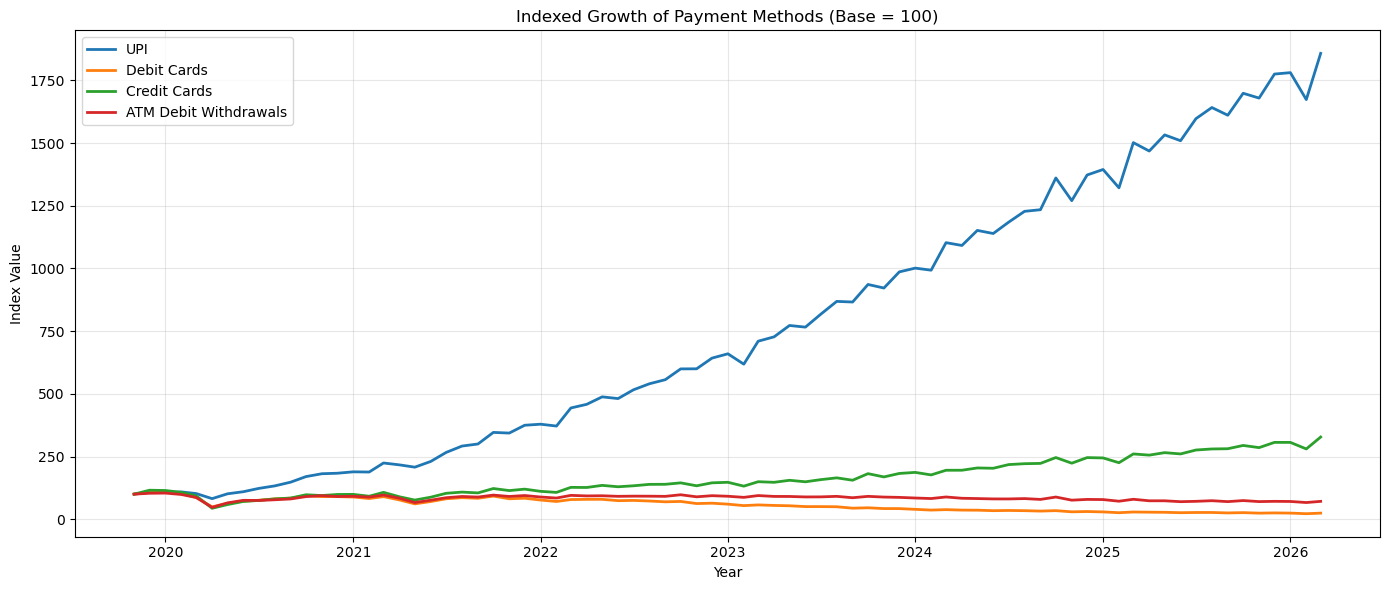

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    normalized['Month'],
    normalized['UPI_Volume_inlakhs'],
    label='UPI',
    linewidth=2
)

plt.plot(
    normalized['Month'],
    normalized['Debit_Volume_inlakhs'],
    label='Debit Cards',
    linewidth=2
)

plt.plot(
    normalized['Month'],
    normalized['Credit_Volume_inlakhs'],
    label='Credit Cards',
    linewidth=2
)

plt.plot(
    normalized['Month'],
    normalized['ATM_Debit_Volume_inlakhs'],
    label='ATM Debit Withdrawals',
    linewidth=2
)

plt.title('Indexed Growth of Payment Methods (Base = 100)')
plt.xlabel('Year')
plt.ylabel('Index Value')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

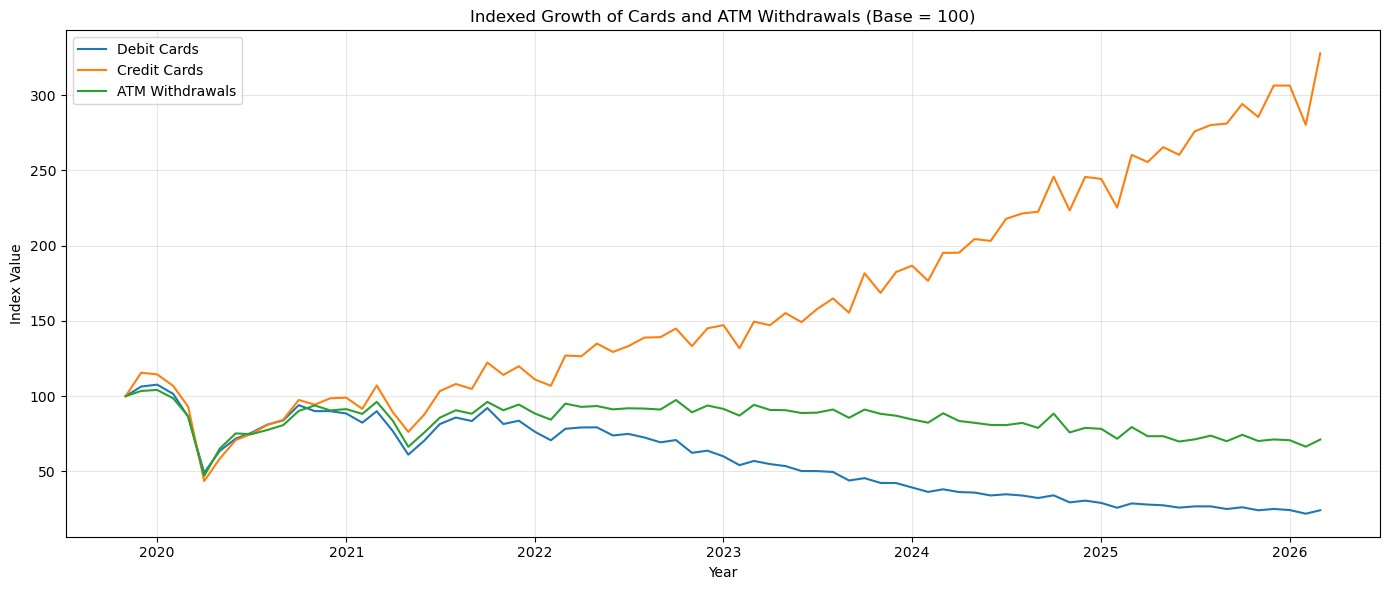

In [43]:
plt.figure(figsize=(14,6))

plt.plot(normalized['Month'], normalized['Debit_Volume_inlakhs'], label='Debit Cards')
plt.plot(normalized['Month'], normalized['Credit_Volume_inlakhs'], label='Credit Cards')
plt.plot(normalized['Month'], normalized['ATM_Debit_Volume_inlakhs'], label='ATM Withdrawals')

plt.title('Indexed Growth of Cards and ATM Withdrawals (Base = 100)')
plt.xlabel('Year')
plt.ylabel('Index Value')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation 

The indexed growth chart compares UPI, debit cards, credit cards, and ATM debit withdrawals using a common base value of 100.

UPI shows the strongest growth by a wide margin, which indicates that it became a major part of India's payment ecosystem. 

We can also observe that debit card transaction volume declined sharply over the same period, while ATM debit withdrawals declined moderately. In contrast, credit card transactions continued to grow alongside UPI. 

ATM debit withdrawals declined, but the decline was not as sharp as debit card payments. This is important because it prevents us from claiming that UPI completely replaced cash usage.

Debit cards appear to have been the most negatively associated with UPI growth, while credit cards continued to grow because they likely serve different consumer needs.

This observation suggests that UPI did not replace all payment methods equally. 

# Insight 3: UPI Became an Everyday Payment Method

Average transaction value helps identify the type of transactions each payment method supports.

Since the RBI dataset reports volume in lakh and value in ₹ crore:

Average Transaction Value = (Value in ₹ Crore × 100) / Volume in Lakh

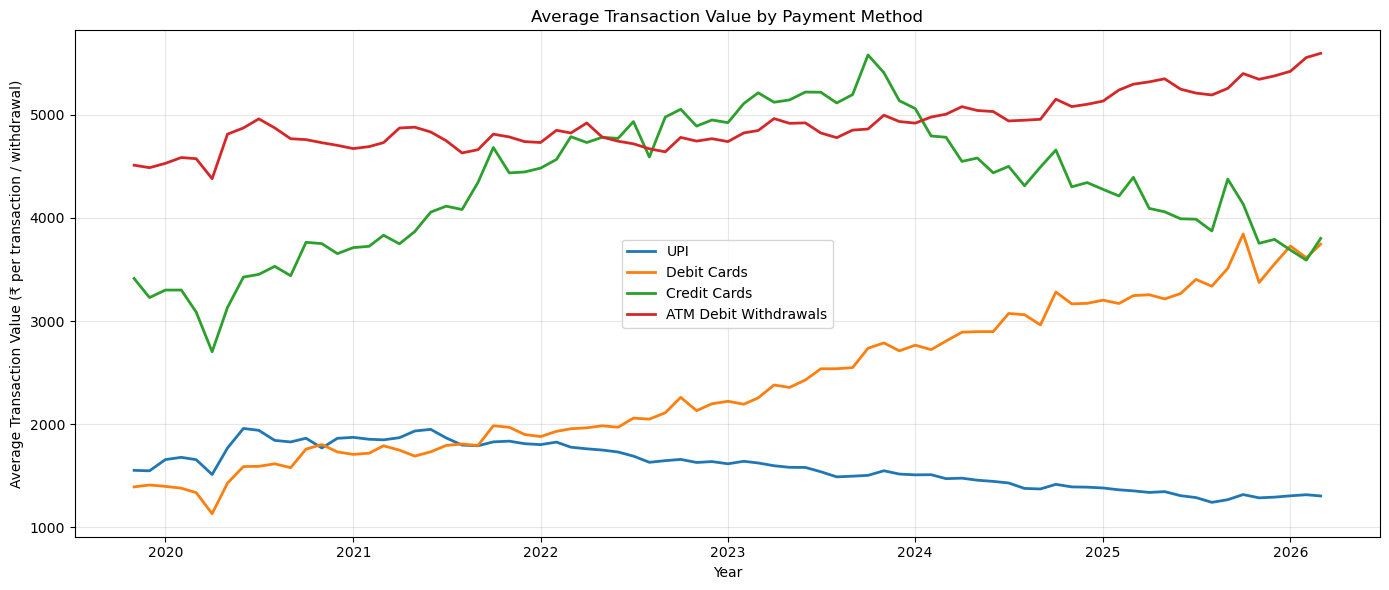

In [40]:
plt.figure(figsize=(14,6))

plt.plot(payments['Month'], payments['UPI_ATV'], label='UPI', linewidth=2)
plt.plot(payments['Month'], payments['Debit_ATV'], label='Debit Cards', linewidth=2)
plt.plot(payments['Month'], payments['Credit_ATV'], label='Credit Cards', linewidth=2)
plt.plot(payments['Month'], payments['ATM_Debit_ATV'], label='ATM Debit Withdrawals', linewidth=2)

plt.title('Average Transaction Value by Payment Method')
plt.xlabel('Year')
plt.ylabel('Average Transaction Value (₹ per transaction / withdrawal)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

UPI consistently had the lowest average transaction value among the payment methods analyzed.

This suggests that UPI is primarily used for frequent low-to-medium value transactions, making it strongly associated with everyday payments.

Credit cards showed a higher average transaction value, which helps explain why they continued to grow alongside UPI. Credit cards likely serve different use cases such as larger purchases, credit access, rewards, EMI, and deferred payments.

Debit card average transaction value increased despite declining transaction volume. This suggests that debit cards may have lost frequent small-payment use cases while remaining relevant for relatively larger transactions.

ATM debit withdrawals had the highest average value, but this represents cash withdrawn per ATM transaction rather than purchase payment value.

### Final Interpretation

From this analysis, we can suggest that UPI did change the way India pays. Users appear to have shifted more toward UPI, while debit card transaction volume declined during the same period. This suggests that debit cards may have become less relevant for everyday payments as UPI became more convenient and widely adopted.

We can also see a decline in ATM debit withdrawals, but the decline is not as sharp as the decline in debit card transactions. Since ATM debit withdrawals are used here as a proxy for cash usage, it is not safe to directly claim that UPI replaced cash. However, the trend does suggest that UPI may have contributed to some reduction in cash withdrawal behavior.

At the same time, this analysis does not prove causation. The results show associations and trends, so we cannot directly prove that UPI caused the decline in debit cards or ATM withdrawals.

On the other hand, credit card transaction volume increased during the same period. This may be because credit cards serve a different role, such as short-term credit, EMI options, rewards, and larger purchases.


In [44]:
plt.savefig("../visualizations/upi_volume_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [45]:
plt.savefig("../visualizations/indexed_payment_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [46]:
plt.savefig("../visualizations/average_transaction_value.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>